In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank_for_students.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59.0,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042.0,1,-1,0,unknown,yes
1,56.0,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467.0,1,-1,0,unknown,yes
2,41.0,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389.0,1,-1,0,unknown,yes
3,55.0,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579.0,1,-1,0,unknown,yes
4,54.0,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673.0,2,-1,0,unknown,yes


In [2]:
df.shape

(11162, 17)

In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [4]:
df.dtypes

age          object
job          object
marital      object
education    object
default      object
balance      object
housing      object
loan         object
contact      object
day           int64
month        object
duration     object
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11042 non-null  object
 1   job        11062 non-null  object
 2   marital    11162 non-null  object
 3   education  11062 non-null  object
 4   default    11162 non-null  object
 5   balance    11042 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11062 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11043 non-null  object
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11062 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(4), object(13)
memory usage: 1.4+ MB


In [6]:
df.isnull().sum()

age          120
job          100
marital        0
education    100
default        0
balance      120
housing        0
loan           0
contact      100
day            0
month          0
duration     119
campaign       0
pdays          0
previous       0
poutcome     100
deposit        0
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

age          1.075076
job          0.895897
marital      0.000000
education    0.895897
default      0.000000
balance      1.075076
housing      0.000000
loan         0.000000
contact      0.895897
day          0.000000
month        0.000000
duration     1.066117
campaign     0.000000
pdays        0.000000
previous     0.000000
poutcome     0.895897
deposit      0.000000
dtype: float64

In [8]:
# Combined version 

missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing

,Missing_Count,Missing_Percentage
age,120,1.075076
job,100,0.895897
marital,0,0.000000
education,100,0.895897
default,0,0.000000
balance,120,1.075076
housing,0,0.000000
loan,0,0.000000
contact,100,0.895897
day,0,0.000000


In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

age            87
job            12
marital         3
education       4
default         2
balance      3789
housing         2
loan            2
contact         3
day            31
month          12
duration     1435
campaign       46
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

In [11]:
df['job'].value_counts(dropna=False)

job
management       2544
blue-collar      1921
technician       1803
admin.           1326
services          917
retired           771
self-employed     401
unemployed        357
student           356
entrepreneur      322
housemaid         274
NaN               100
unknown            70
Name: count, dtype: int64

In [12]:
df['marital'].value_counts(dropna=False)

marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

In [13]:
df['education'].value_counts(dropna=False)

education
secondary    5431
tertiary     3651
primary      1488
unknown       492
NaN           100
Name: count, dtype: int64

In [14]:
df['default'].value_counts(dropna=False)

default
no     10994
yes      168
Name: count, dtype: int64

In [15]:
df['housing'].value_counts(dropna=False)

housing
no     5881
yes    5281
Name: count, dtype: int64

In [16]:
df['loan'].value_counts(dropna=False)

loan
no     9702
yes    1460
Name: count, dtype: int64

In [17]:
df['contact'].value_counts(dropna=False)

contact
cellular     7971
unknown      2323
telephone     768
NaN           100
Name: count, dtype: int64

In [18]:
df['month'].value_counts(dropna=False)

month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64

In [19]:
df['poutcome'].value_counts(dropna=False)

poutcome
unknown    8257
failure    1212
success    1063
other       530
NaN         100
Name: count, dtype: int64

In [20]:
df['deposit'].value_counts(dropna=False)

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [21]:
df.describe()

,day,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000
mean,15.658036,2.631966,51.330407,0.832557
std,8.420740,5.042158,108.758282,2.292007
min,1.000000,1.000000,-1.000000,0.000000
25%,8.000000,1.000000,-1.000000,0.000000
50%,15.000000,2.000000,-1.000000,0.000000
75%,22.000000,3.000000,20.750000,1.000000
max,31.000000,198.000000,854.000000,58.000000


In [22]:
df['age'].unique()[:20]

array(['59.0', '56.0', '41.0', '55.0', '54.0', '42.0', '60.0', '37.0',
       '28.0', '38.0', '30.0', '29.0', '46.0', '31.0', '35.0', '32.0',
       '49.0', '43.0', '26.0', '40.0'], dtype=object)

In [23]:
df['balance'].unique()[:20]

array(['2343.0', '45.0', '1270.0', '2476.0', '184.0', '0.0', '830.0',
       '545.0', '1.0', '5090.0', '100.0', '309.0', '199.0', '460.0',
       '703.0', '3837.0', '611.0', '-8.0', '55.0', '168.0'], dtype=object)

In [24]:
df['duration'].unique()[:20]

array(['1042.0', '1467.0', '1389.0', '579.0', '673.0', '562.0', '1201.0',
       '1030.0', '608.0', '1297.0', '786.0', '1574.0', '1689.0', '1102.0',
       '943.0', '1084.0', '541.0', '1119.0', '1120.0', '513.0'],
      dtype=object)

In [25]:
# Finding non-numeric values


In [26]:
pd.to_numeric(df['age'], errors='coerce').isna().sum()

125

In [27]:
pd.to_numeric(df['balance'], errors='coerce').isna().sum()

125

In [28]:
pd.to_numeric(df['duration'], errors='coerce').isna().sum()

124

In [29]:
# Actually identify those problematic values

In [30]:
age_numeric = pd.to_numeric(df['age'], errors='coerce')

df.loc[age_numeric.isna(), 'age'].value_counts(dropna=False)

age
NaN        120
unknown      5
Name: count, dtype: int64

In [31]:
balance_numeric = pd.to_numeric(df['balance'], errors='coerce')

df.loc[balance_numeric.isna(), 'balance'].value_counts(dropna=False)

balance
NaN              120
not_available      5
Name: count, dtype: int64

In [32]:
duration_numeric = pd.to_numeric(df['duration'], errors='coerce')

df.loc[duration_numeric.isna(), 'duration'].value_counts(dropna=False)

duration
NaN        119
missing      5
Name: count, dtype: int64

In [33]:
df.loc[
    pd.to_numeric(df['age'], errors='coerce').isna(),
    'age'
].value_counts(dropna=False)

age
NaN        120
unknown      5
Name: count, dtype: int64

In [34]:
df.loc[
    pd.to_numeric(df['balance'], errors='coerce').isna(),
    'balance'
].value_counts(dropna=False)

balance
NaN              120
not_available      5
Name: count, dtype: int64

In [35]:
df.loc[
    pd.to_numeric(df['duration'], errors='coerce').isna(),
    'duration'
].value_counts(dropna=False)

duration
NaN        119
missing      5
Name: count, dtype: int64

In [36]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['balance'] = pd.to_numeric(df['balance'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

In [37]:
df[['age', 'balance', 'duration']].dtypes

age         float64
balance     float64
duration    float64
dtype: object

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        11037 non-null  float64
 1   job        11062 non-null  object 
 2   marital    11162 non-null  object 
 3   education  11062 non-null  object 
 4   default    11162 non-null  object 
 5   balance    11037 non-null  float64
 6   housing    11162 non-null  object 
 7   loan       11162 non-null  object 
 8   contact    11062 non-null  object 
 9   day        11162 non-null  int64  
 10  month      11162 non-null  object 
 11  duration   11038 non-null  float64
 12  campaign   11162 non-null  int64  
 13  pdays      11162 non-null  int64  
 14  previous   11162 non-null  int64  
 15  poutcome   11062 non-null  object 
 16  deposit    11162 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 1.4+ MB


In [39]:
df[['age', 'balance', 'duration']].isnull().sum()

age         125
balance     125
duration    124
dtype: int64

In [40]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 32.0
Q3: 49.0
IQR: 17.0
Lower Bound: 6.5
Upper Bound: 74.5


In [41]:
age_outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

age_outliers[['age', 'job', 'education', 'balance', 'deposit']].head(20)

,age,job,education,balance,deposit
541,134.0,admin.,unknown,349.0,yes
1162,75.0,retired,primary,3881.0,yes
1243,90.0,retired,secondary,1.0,yes
1274,85.0,retired,primary,7613.0,yes
1320,83.0,retired,primary,1097.0,yes
1371,76.0,retired,primary,3049.0,yes
1373,83.0,retired,primary,46.0,yes
1380,77.0,retired,secondary,9601.0,yes
1472,77.0,retired,tertiary,4659.0,yes
1487,76.0,housemaid,primary,1411.0,yes


In [42]:
len(age_outliers)

179

In [43]:
df[df['age'] > 100][
    ['age', 'job', 'marital', 'education', 'balance', 'deposit']
]

,age,job,marital,education,balance,deposit
541,134.0,admin.,married,unknown,349.0,yes
1679,123.0,services,married,secondary,1337.0,yes
2135,124.0,management,married,tertiary,243.0,yes
2753,138.0,admin.,divorced,secondary,592.0,yes
3688,146.0,student,single,secondary,1809.0,yes
5140,127.0,management,married,tertiary,5969.0,yes
5383,141.0,blue-collar,married,secondary,0.0,no
5519,139.0,management,single,tertiary,0.0,no
6737,127.0,blue-collar,married,primary,625.0,no
7940,122.0,retired,married,secondary,0.0,no


In [44]:
(df['age'] > 100).sum()

12

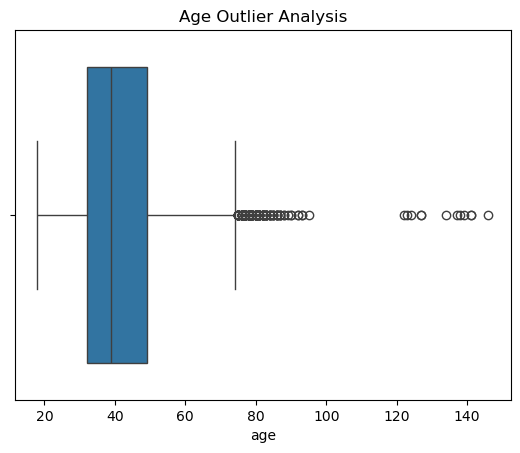

In [45]:
sns.boxplot(x=df['age'])
plt.title('Age Outlier Analysis')
plt.show()

In [46]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    
    return outliers

In [47]:
age_outliers = find_outliers_iqr(df, 'age')

Column: age
Q1: 32.0
Q3: 49.0
IQR: 17.0
Lower Bound: 6.5
Upper Bound: 74.5
Number of Outliers: 179


In [48]:
balance_outliers = find_outliers_iqr(df, 'balance')

Column: balance
Q1: 122.0
Q3: 1716.0
IQR: 1594.0
Lower Bound: -2269.0
Upper Bound: 4107.0
Number of Outliers: 1052


In [49]:
balance_outliers = find_outliers_iqr(df, 'duration')

Column: duration
Q1: 138.0
Q3: 497.75
IQR: 359.75
Lower Bound: -401.625
Upper Bound: 1037.375
Number of Outliers: 630


In [50]:
balance_outliers = find_outliers_iqr(df, 'campaign')

Column: campaign
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 611


In [51]:
age_outliers = find_outliers_iqr(df, 'age')

age_outliers[['age', 'job', 'education', 'balance', 'deposit']]

Column: age
Q1: 32.0
Q3: 49.0
IQR: 17.0
Lower Bound: 6.5
Upper Bound: 74.5
Number of Outliers: 179


,age,job,education,balance,deposit
541,134.0,admin.,unknown,349.0,yes
1162,75.0,retired,primary,3881.0,yes
1243,90.0,retired,secondary,1.0,yes
1274,85.0,retired,primary,7613.0,yes
1320,83.0,retired,primary,1097.0,yes
...,...,...,...,...,...
10438,77.0,retired,primary,1492.0,no
10562,88.0,retired,primary,648.0,no
10570,77.0,unknown,unknown,397.0,no
10618,78.0,retired,primary,680.0,no


In [52]:
invalid_age = df[
    (df['age'] < 18) |
    (df['age'] > 100)
]

invalid_age[['age', 'job', 'education', 'balance', 'deposit']]

,age,job,education,balance,deposit
541,134.0,admin.,unknown,349.0,yes
1679,123.0,services,secondary,1337.0,yes
2135,124.0,management,tertiary,243.0,yes
2753,138.0,admin.,secondary,592.0,yes
3688,146.0,student,secondary,1809.0,yes
5140,127.0,management,tertiary,5969.0,yes
5383,141.0,blue-collar,secondary,0.0,no
5519,139.0,management,tertiary,0.0,no
6737,127.0,blue-collar,primary,625.0,no
7940,122.0,retired,secondary,0.0,no


In [53]:
len(invalid_age)

12

In [54]:
df[df['age'] > 100]['age'].sort_values()

7940     122.0
1679     123.0
2135     124.0
5140     127.0
6737     127.0
541      134.0
9640     137.0
2753     138.0
5519     139.0
5383     141.0
10376    141.0
3688     146.0
Name: age, dtype: float64

In [55]:
invalid_age = df[(df['age'] < 18) | (df['age'] > 100)]

print("Invalid age records:", len(invalid_age))
print("Ages above 100:", sorted(df[df['age'] > 100]['age'].dropna().unique()))

Invalid age records: 12
Ages above 100: [122.0, 123.0, 124.0, 127.0, 134.0, 137.0, 138.0, 139.0, 141.0, 146.0]


In [56]:
df.loc[(df['age'] < 18) | (df['age'] > 100), 'age'] = np.nan

In [57]:
df['age'].isna().sum()

137

In [58]:
age_median = df['age'].median()
print(age_median)

39.0


In [59]:
df['age'] = df['age'].fillna(age_median)

In [60]:
print("Minimum age:", df['age'].min())
print("Maximum age:", df['age'].max())
print("Missing ages:", df['age'].isna().sum())

Minimum age: 18.0
Maximum age: 95.0
Missing ages: 0


In [61]:
balance_outliers = find_outliers_iqr(df, 'balance')

Column: balance
Q1: 122.0
Q3: 1716.0
IQR: 1594.0
Lower Bound: -2269.0
Upper Bound: 4107.0
Number of Outliers: 1052


In [62]:
balance_outliers[['balance', 'job', 'education', 'age', 'deposit']].sort_values('balance')

,balance,job,education,age,deposit
9546,-250000.0,blue-collar,secondary,30.0,no
11104,-150000.0,blue-collar,secondary,30.0,no
8623,-150000.0,technician,tertiary,42.0,no
1815,-150000.0,management,secondary,49.0,yes
5946,-100000.0,services,secondary,38.0,no
...,...,...,...,...,...
10003,350000.0,management,unknown,49.0,no
3249,350000.0,retired,secondary,82.0,yes
2773,350000.0,technician,secondary,40.0,yes
3129,500000.0,entrepreneur,secondary,33.0,yes


In [63]:
print("Minimum balance:", df['balance'].min())
print("Maximum balance:", df['balance'].max())

Minimum balance: -250000.0
Maximum balance: 500000.0


In [64]:
df[df['balance'] < 0]['balance'].sort_values()

9546    -250000.0
11104   -150000.0
8623    -150000.0
1815    -150000.0
5946    -100000.0
           ...   
10165        -1.0
2082         -1.0
59           -1.0
30           -1.0
8279         -1.0
Name: balance, Length: 686, dtype: float64

In [65]:
print(df['balance'].value_counts().sort_index().head(20))

balance
-250000.0    1
-150000.0    3
-100000.0    3
-6847.0      1
-3058.0      1
-2712.0      1
-2282.0      1
-2049.0      1
-1965.0      1
-1944.0      1
-1701.0      1
-1636.0      1
-1531.0      1
-1489.0      1
-1451.0      1
-1415.0      2
-1386.0      1
-1206.0      1
-1139.0      1
-1137.0      1
Name: count, dtype: int64


In [66]:
print(df['balance'].value_counts().sort_index().tail(20))

balance
29184.0     1
29207.0     1
29340.0     1
31472.0     1
31868.0     1
32685.0     1
34230.0     1
34646.0     1
36252.0     1
36935.0     1
37127.0     1
45248.0     1
51439.0     1
52587.0     2
56831.0     1
66653.0     1
81204.0     2
250000.0    3
350000.0    3
500000.0    2
Name: count, dtype: int64


In [67]:
print(df['balance'].value_counts().sort_values(ascending=False).head(20))

balance
0.0      766
1.0       37
3.0       35
2.0       34
4.0       29
5.0       27
19.0      20
8.0       19
62.0      18
6.0       17
61.0      17
21.0      17
67.0      16
16.0      16
205.0     16
154.0     16
22.0      16
294.0     16
46.0      16
127.0     15
Name: count, dtype: int64


In [68]:
duration_outliers = find_outliers_iqr(df, 'duration')

Column: duration
Q1: 138.0
Q3: 497.75
IQR: 359.75
Lower Bound: -401.625
Upper Bound: 1037.375
Number of Outliers: 630


In [69]:
duration_outliers[['duration', 'job', 'age', 'balance', 'campaign', 'deposit']].sort_values('duration')

,duration,job,age,balance,campaign,deposit
1869,1038.0,admin.,41.0,-109.0,1,yes
1489,1038.0,technician,27.0,439.0,2,yes
479,1039.0,services,42.0,3465.0,2,yes
5253,1039.0,blue-collar,31.0,-537.0,7,yes
5109,1039.0,admin.,48.0,3644.0,9,yes
...,...,...,...,...,...,...
212,15778.0,blue-collar,29.0,260.0,14,yes
3364,17944.0,management,62.0,3371.0,1,yes
9218,19242.0,management,66.0,2149.0,6,no
9430,19918.0,retired,89.0,553.0,5,no


In [70]:
print("Minimum duration:", df['duration'].min())
print("Maximum duration:", df['duration'].max())

Minimum duration: 2.0
Maximum duration: 19931.0


In [71]:
print(df['duration'].sort_values(ascending=False).head(20))

8242    19931.0
9430    19918.0
9218    19242.0
3364    17944.0
212     15778.0
3540    15534.0
1845    15073.0
7352    12650.0
7900    11729.0
7830    11213.0
8090    10165.0
4274    10040.0
271      3881.0
7198     3284.0
883      3253.0
358      3183.0
4364     3102.0
153      3094.0
1351     3076.0
1179     2775.0
Name: duration, dtype: float64


In [72]:
campaign_outliers = find_outliers_iqr(df, 'campaign')

Column: campaign
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 611


In [73]:
campaign_outliers[['campaign', 'job', 'age', 'balance', 'duration', 'deposit']].sort_values('campaign')

,campaign,job,age,balance,duration,deposit
10682,7,admin.,25.0,184.0,437.0,no
10897,7,blue-collar,30.0,906.0,218.0,no
10534,7,blue-collar,51.0,0.0,61.0,no
10543,7,services,56.0,530.0,51.0,no
7478,7,management,52.0,NaN,30.0,no
...,...,...,...,...,...,...
5984,134,management,46.0,0.0,38.0,no
1415,160,self-employed,26.0,3676.0,148.0,yes
6388,167,management,51.0,-2282.0,301.0,no
10011,184,services,28.0,6332.0,149.0,no


In [74]:
print("Minimum campaign:", df['campaign'].min())
print("Maximum campaign:", df['campaign'].max())

Minimum campaign: 1
Maximum campaign: 198


In [75]:
print(df['campaign'].value_counts().sort_index())

campaign
1      4794
2      3027
3      1318
4       771
5       378
6       263
7       139
8       128
9        72
10       52
11       40
12       29
13       30
14       15
15       13
16        9
17       14
18        8
19        5
20        5
21        8
22        4
23        3
24        5
25        3
26        3
27        1
28        1
29        2
30        4
31        1
32        2
33        1
41        1
43        2
63        1
101       1
105       1
115       1
119       1
123       1
134       1
160       1
167       1
184       1
198       1
Name: count, dtype: int64


In [76]:
previous_outliers = find_outliers_iqr(df, 'previous')

Column: previous
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 1258


In [77]:
previous_outliers[['previous', 'pdays', 'poutcome', 'campaign', 'deposit']].sort_values('previous')

,previous,pdays,poutcome,campaign,deposit
7142,3,105,success,2,no
3585,3,278,success,1,yes
6599,3,92,success,1,no
6630,3,162,failure,2,no
3554,3,353,other,2,yes
...,...,...,...,...,...
10121,37,95,other,6,no
8713,40,270,other,3,no
6274,41,778,other,1,no
3677,55,776,failure,3,yes


In [78]:
print("Minimum previous:", df['previous'].min())
print("Maximum previous:", df['previous'].max())

Minimum previous: 0
Maximum previous: 58


In [79]:
print(df['previous'].value_counts().sort_index())

previous
0     8324
1      887
2      693
3      435
4      244
5      165
6      117
7       77
8       60
9       34
10      30
11      23
12      16
13      11
14       6
15       5
16       2
17      11
18       1
19       4
20       2
21       1
22       1
23       2
26       1
27       2
28       1
29       1
30       1
37       1
40       1
41       1
55       1
58       1
Name: count, dtype: int64


In [80]:
# Categorical Data Validation

In [81]:
categorical_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month',
    'poutcome', 'deposit'
]


In [82]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- job ---
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed' nan
 'student']

--- marital ---
['married' 'single' 'divorced']

--- education ---
['secondary' 'tertiary' 'primary' 'unknown' nan]

--- default ---
['no' 'yes']

--- housing ---
['yes' 'no']

--- loan ---
['no' 'yes']

--- contact ---
['unknown' nan 'cellular' 'telephone']

--- month ---
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

--- poutcome ---
['unknown' nan 'other' 'failure' 'success']

--- deposit ---
['yes' 'no']


In [83]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- job ---
job
management       2544
blue-collar      1921
technician       1803
admin.           1326
services          917
retired           771
self-employed     401
unemployed        357
student           356
entrepreneur      322
housemaid         274
NaN               100
unknown            70
Name: count, dtype: int64

--- marital ---
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

--- education ---
education
secondary    5431
tertiary     3651
primary      1488
unknown       492
NaN           100
Name: count, dtype: int64

--- default ---
default
no     10994
yes      168
Name: count, dtype: int64

--- housing ---
housing
no     5881
yes    5281
Name: count, dtype: int64

--- loan ---
loan
no     9702
yes    1460
Name: count, dtype: int64

--- contact ---
contact
cellular     7971
unknown      2323
telephone     768
NaN           100
Name: count, dtype: int64

--- month ---
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943

In [84]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(sorted(df[col].dropna().astype(str).unique()))
    


--- job ---
['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

--- marital ---
['divorced', 'married', 'single']

--- education ---
['primary', 'secondary', 'tertiary', 'unknown']

--- default ---
['no', 'yes']

--- housing ---
['no', 'yes']

--- loan ---
['no', 'yes']

--- contact ---
['cellular', 'telephone', 'unknown']

--- month ---
['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

--- poutcome ---
['failure', 'other', 'success', 'unknown']

--- deposit ---
['no', 'yes']


In [85]:
df[col].dropna()

0        yes
1        yes
2        yes
3        yes
4        yes
        ... 
11157     no
11158     no
11159     no
11160     no
11161     no
Name: deposit, Length: 11162, dtype: object

In [86]:
# Check outcome categories and counts

In [87]:
print("Target Variable: deposit")
print("\nCategories:")
print(df['deposit'].unique())

print("\nCustomer count by outcome:")
print(df['deposit'].value_counts())

Target Variable: deposit

Categories:
['yes' 'no']

Customer count by outcome:
deposit
no     5873
yes    5289
Name: count, dtype: int64


In [88]:
target_counts = df['deposit'].value_counts()
target_percentage = df['deposit'].value_counts(normalize=True) * 100

print("Target Distribution:")
print(pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_percentage.round(2)
}))

Target Distribution:
         Count  Percentage
deposit                   
no        5873       52.62
yes       5289       47.38


In [89]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 11162
Columns: 17


In [90]:
print(df.dtypes)

age          float64
job           object
marital       object
education     object
default       object
balance      float64
housing       object
loan          object
contact       object
day            int64
month         object
duration     float64
campaign       int64
pdays          int64
previous       int64
poutcome      object
deposit       object
dtype: object


In [91]:
numeric_cols = [
    'age', 'balance', 'day',
    'duration', 'campaign', 'pdays', 'previous'
]

print(df[numeric_cols].dtypes)

age         float64
balance     float64
day           int64
duration    float64
campaign      int64
pdays         int64
previous      int64
dtype: object


In [92]:
print(df.isnull().sum())

age            0
job          100
marital        0
education    100
default        0
balance      125
housing        0
loan           0
contact      100
day            0
month          0
duration     124
campaign       0
pdays          0
previous       0
poutcome     100
deposit        0
dtype: int64


In [93]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [94]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- job ---
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed' nan
 'student']

--- marital ---
['married' 'single' 'divorced']

--- education ---
['secondary' 'tertiary' 'primary' 'unknown' nan]

--- default ---
['no' 'yes']

--- housing ---
['yes' 'no']

--- loan ---
['no' 'yes']

--- contact ---
['unknown' nan 'cellular' 'telephone']

--- month ---
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

--- poutcome ---
['unknown' nan 'other' 'failure' 'success']

--- deposit ---
['yes' 'no']


In [95]:
print(df[numeric_cols].describe().T)

            count         mean           std       min    25%    50%      75%  \
age       11162.0    41.186436     11.825127      18.0   32.0   39.0    49.00   
balance   11037.0  1692.999094  10955.315192 -250000.0  122.0  551.0  1716.00   
day       11162.0    15.658036      8.420740       1.0    8.0   15.0    22.00   
duration  11038.0   387.756478    603.826697       2.0  138.0  255.0   497.75   
campaign  11162.0     2.631966      5.042158       1.0    1.0    2.0     3.00   
pdays     11162.0    51.330407    108.758282      -1.0   -1.0   -1.0    20.75   
previous  11162.0     0.832557      2.292007       0.0    0.0    0.0     1.00   

               max  
age           95.0  
balance   500000.0  
day           31.0  
duration   19931.0  
campaign     198.0  
pdays        854.0  
previous      58.0  


In [96]:
print("Age range:", df['age'].min(), "to", df['age'].max())

Age range: 18.0 to 95.0


In [97]:
print("Campaign range:", df['campaign'].min(), "to", df['campaign'].max())

Campaign range: 1 to 198


In [98]:
print("Previous range:", df['previous'].min(), "to", df['previous'].max())

Previous range: 0 to 58


In [99]:
print("Pdays range:", df['pdays'].min(), "to", df['pdays'].max())

Pdays range: -1 to 854


In [100]:
print(df['deposit'].value_counts(dropna=False))

deposit
no     5873
yes    5289
Name: count, dtype: int64


In [101]:
print("Missing target values:", df['deposit'].isnull().sum())

Missing target values: 0


In [102]:
pd.crosstab(df['job'], df['marital'])

marital,divorced,married,single
job,,,
admin.,180,676,470
blue-collar,149,1317,455
entrepreneur,41,229,52
housemaid,46,190,38
management,287,1415,842
retired,169,576,26
self-employed,37,220,144
services,121,499,297
student,2,15,339


In [103]:
pd.crosstab(df['job'], df['marital']).loc['management']

marital
divorced     287
married     1415
single       842
Name: management, dtype: int64

In [104]:
import pandas as pd

# Cross-tabulation between Job and Marital Status
job_marital = pd.crosstab(df['job'], df['marital'])

# Display all job categories with marital status counts
print(job_marital)

# Display only Management employees
print("\nManagement Employees:")
print(job_marital.loc['management'])

# Display management employees by marital status
print("\nManagement Marital Status Counts:")
print("Married:", job_marital.loc['management', 'married'])
print("Single:", job_marital.loc['management', 'single'])
print("Divorced:", job_marital.loc['management', 'divorced'])

marital        divorced  married  single
job                                     
admin.              180      676     470
blue-collar         149     1317     455
entrepreneur         41      229      52
housemaid            46      190      38
management          287     1415     842
retired             169      576      26
self-employed        37      220     144
services            121      499     297
student               2       15     339
technician          203      919     681
unemployed           47      186     124
unknown               2       49      19

Management Employees:
marital
divorced     287
married     1415
single       842
Name: management, dtype: int64

Management Marital Status Counts:
Married: 1415
Single: 842
Divorced: 287


In [105]:
# Among married, single and divorced customers, what percentage subscribed?

In [106]:
# Management + Married customers and their deposit status

management_married = df[
    (df['job'] == 'management') &
    (df['marital'] == 'married')
]

print("Total Management + Married customers:", len(management_married))

print("\nDeposit Status:")
print(management_married['deposit'].value_counts())

print("\nPercentage:")
print(management_married['deposit'].value_counts(normalize=True) * 100)

Total Management + Married customers: 1415

Deposit Status:
deposit
no     740
yes    675
Name: count, dtype: int64

Percentage:
deposit
no     52.29682
yes    47.70318
Name: proportion, dtype: float64


In [107]:
# Filter Management + Married customers
management_married = df[
    (df['job'] == 'management') &
    (df['marital'] == 'married')
]

# Count subscribed and not subscribed
deposit_counts = management_married['deposit'].value_counts()

print(deposit_counts)

deposit
no     740
yes    675
Name: count, dtype: int64


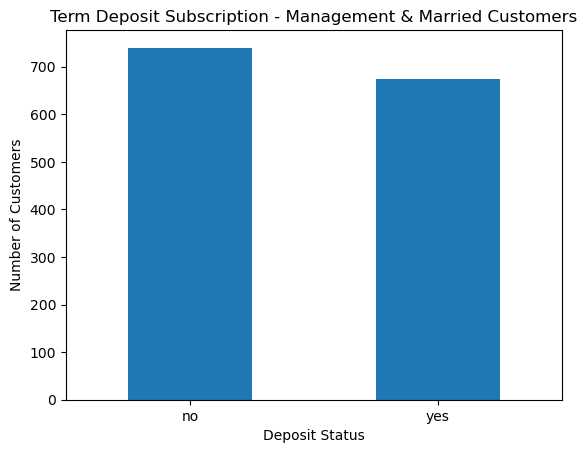

In [108]:
import matplotlib.pyplot as plt

management_married['deposit'].value_counts().plot(kind='bar')

plt.title('Term Deposit Subscription - Management & Married Customers')
plt.xlabel('Deposit Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

deposit     no   yes
marital             
divorced   671   622
married   3596  2755
single    1606  1912


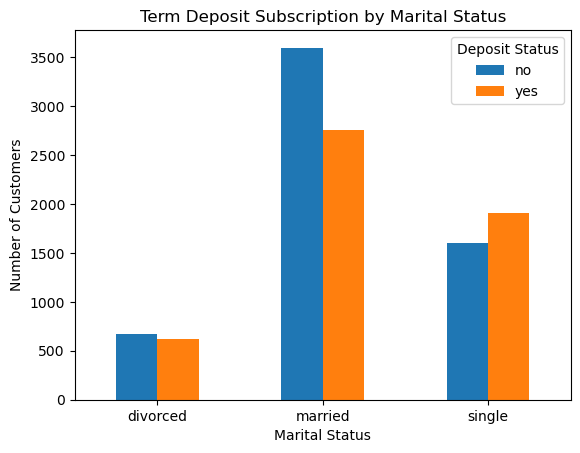

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a cross-tabulation of Marital Status and Deposit Status
marital_deposit = pd.crosstab(df['marital'], df['deposit'])

print(marital_deposit)

# Plot
marital_deposit.plot(kind='bar')

plt.title('Term Deposit Subscription by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Deposit Status')
plt.show()

deposit    no  yes
marital           
divorced  146  141
married   740  675
single    368  474


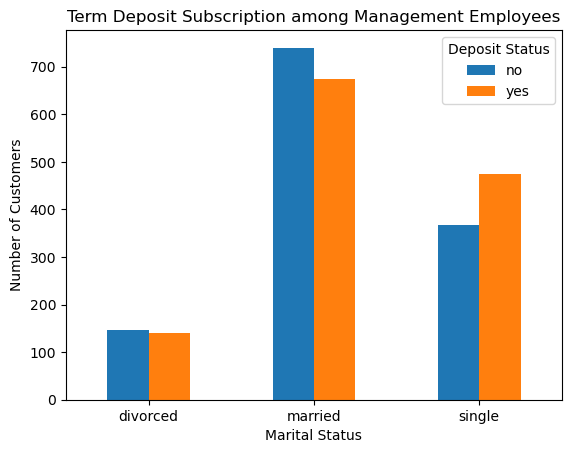

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only Management employees
management = df[df['job'] == 'management']

# Compare Marital Status with Deposit Status
management_marital_deposit = pd.crosstab(
    management['marital'],
    management['deposit']
)

print(management_marital_deposit)

# Plot
management_marital_deposit.plot(kind='bar')

plt.title('Term Deposit Subscription among Management Employees')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Deposit Status')
plt.show()

In [111]:
# Subscription count by marital status
marital_deposit = pd.crosstab(df['marital'], df['deposit'])

print("Counts:")
print(marital_deposit)

# Subscription percentage within each marital group
marital_rate = pd.crosstab(
    df['marital'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Percentage:")
print(marital_rate)

Counts:
deposit     no   yes
marital             
divorced   671   622
married   3596  2755
single    1606  1912

Subscription Percentage:
deposit          no        yes
marital                       
divorced  51.894818  48.105182
married   56.621005  43.378995
single    45.650938  54.349062


In [112]:
one_call = df[df['campaign'] == 1]

print("Customers contacted once:", len(one_call))

Customers contacted once: 4794


In [113]:
print(one_call['job'].value_counts())

job
management       1027
blue-collar       804
technician        696
admin.            644
services          396
retired           385
student           184
self-employed     179
unemployed        173
entrepreneur      126
housemaid         100
unknown            33
Name: count, dtype: int64


In [114]:
print("JOB:")
print(one_call['job'].value_counts())

print("\nMARITAL:")
print(one_call['marital'].value_counts())

print("\nEDUCATION:")
print(one_call['education'].value_counts())

print("\nHOUSING:")
print(one_call['housing'].value_counts())

print("\nLOAN:")
print(one_call['loan'].value_counts())

print("\nCONTACT:")
print(one_call['contact'].value_counts())

print("\nDEPOSIT:")
print(one_call['deposit'].value_counts())

JOB:
job
management       1027
blue-collar       804
technician        696
admin.            644
services          396
retired           385
student           184
self-employed     179
unemployed        173
entrepreneur      126
housemaid         100
unknown            33
Name: count, dtype: int64

MARITAL:
marital
married     2608
single      1620
divorced     566
Name: count, dtype: int64

EDUCATION:
education
secondary    2430
tertiary     1531
primary       577
unknown       214
Name: count, dtype: int64

HOUSING:
housing
no     2520
yes    2274
Name: count, dtype: int64

LOAN:
loan
no     4171
yes     623
Name: count, dtype: int64

CONTACT:
contact
cellular     3506
unknown       957
telephone     289
Name: count, dtype: int64

DEPOSIT:
deposit
yes    2559
no     2235
Name: count, dtype: int64


In [115]:
pd.crosstab(df['campaign'], df['deposit'])

deposit,no,yes
campaign,,
1,2235,2559
2,1627,1400
3,702,616
4,454,317
5,239,139
6,171,92
7,92,47
8,96,32
9,51,21


In [116]:
campaign_deposit_rate = pd.crosstab(
    df['campaign'],
    df['deposit'],
    normalize='index'
) * 100

print(campaign_deposit_rate)

deposit           no         yes
campaign                        
1          46.620776   53.379224
2          53.749587   46.250413
3          53.262519   46.737481
4          58.884565   41.115435
5          63.227513   36.772487
6          65.019011   34.980989
7          66.187050   33.812950
8          75.000000   25.000000
9          70.833333   29.166667
10         73.076923   26.923077
11         60.000000   40.000000
12         86.206897   13.793103
13         80.000000   20.000000
14         73.333333   26.666667
15         69.230769   30.769231
16         77.777778   22.222222
17         57.142857   42.857143
18        100.000000    0.000000
19        100.000000    0.000000
20         80.000000   20.000000
21         87.500000   12.500000
22        100.000000    0.000000
23        100.000000    0.000000
24         80.000000   20.000000
25        100.000000    0.000000
26        100.000000    0.000000
27        100.000000    0.000000
28        100.000000    0.000000
29        

In [117]:
import pandas as pd

# Subscription rate by job
job_subscription = pd.crosstab(
    df['job'],
    df['deposit'],
    normalize='index'
) * 100

print(job_subscription)

deposit               no        yes
job                                
admin.         52.714932  47.285068
blue-collar    63.872983  36.127017
entrepreneur   62.422360  37.577640
housemaid      60.218978  39.781022
management     49.292453  50.707547
retired        33.592737  66.407263
self-employed  54.114713  45.885287
services       59.978190  40.021810
student        25.280899  74.719101
technician     53.854687  46.145313
unemployed     43.417367  56.582633
unknown        51.428571  48.571429


In [118]:
# Which occupations have more subscribers, and which occupations have a higher subscription rate?

INSIGHT

Number of management customers who subscribed
Number who didn't
Subscription rate for management
Compare it with other jobs

Recommendation

The bank can consider that occupational segment as a potentially responsive customer group and design targeted communication for similar customers.


SyntaxError: unterminated string literal (detected at line 6) (2890811956.py, line 6)

In [ ]:
poutcome_subscription = pd.crosstab(
    df['poutcome'],
    df['deposit'],
    normalize='index'
) * 100

print(poutcome_subscription)

In [ ]:

campaign_subscription = pd.crosstab(
    df['campaign'],
    df['deposit'],
    normalize='index'
) * 100

print(campaign_subscription)

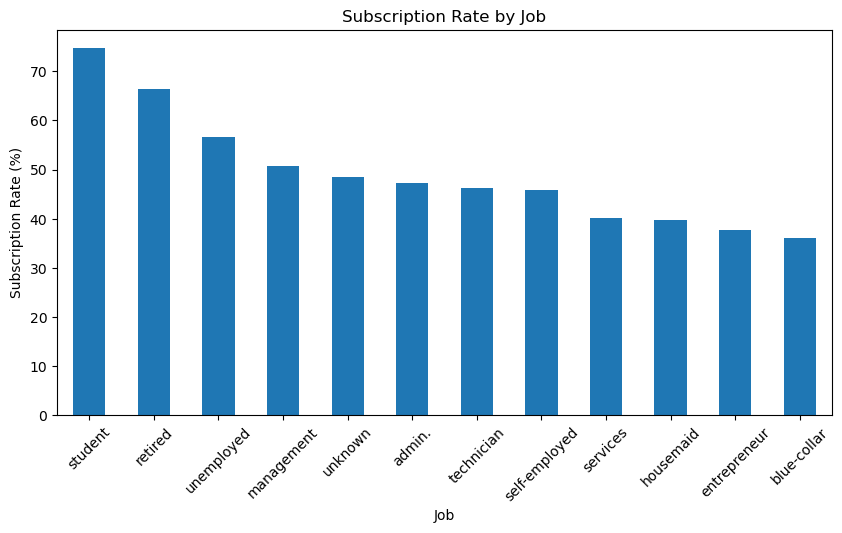

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate subscription percentage for each job
job_subscription = pd.crosstab(
    df['job'],
    df['deposit'],
    normalize='index'
) * 100

# Plot subscribed percentage
job_subscription['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Subscription Rate by Job')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45)
plt.show()

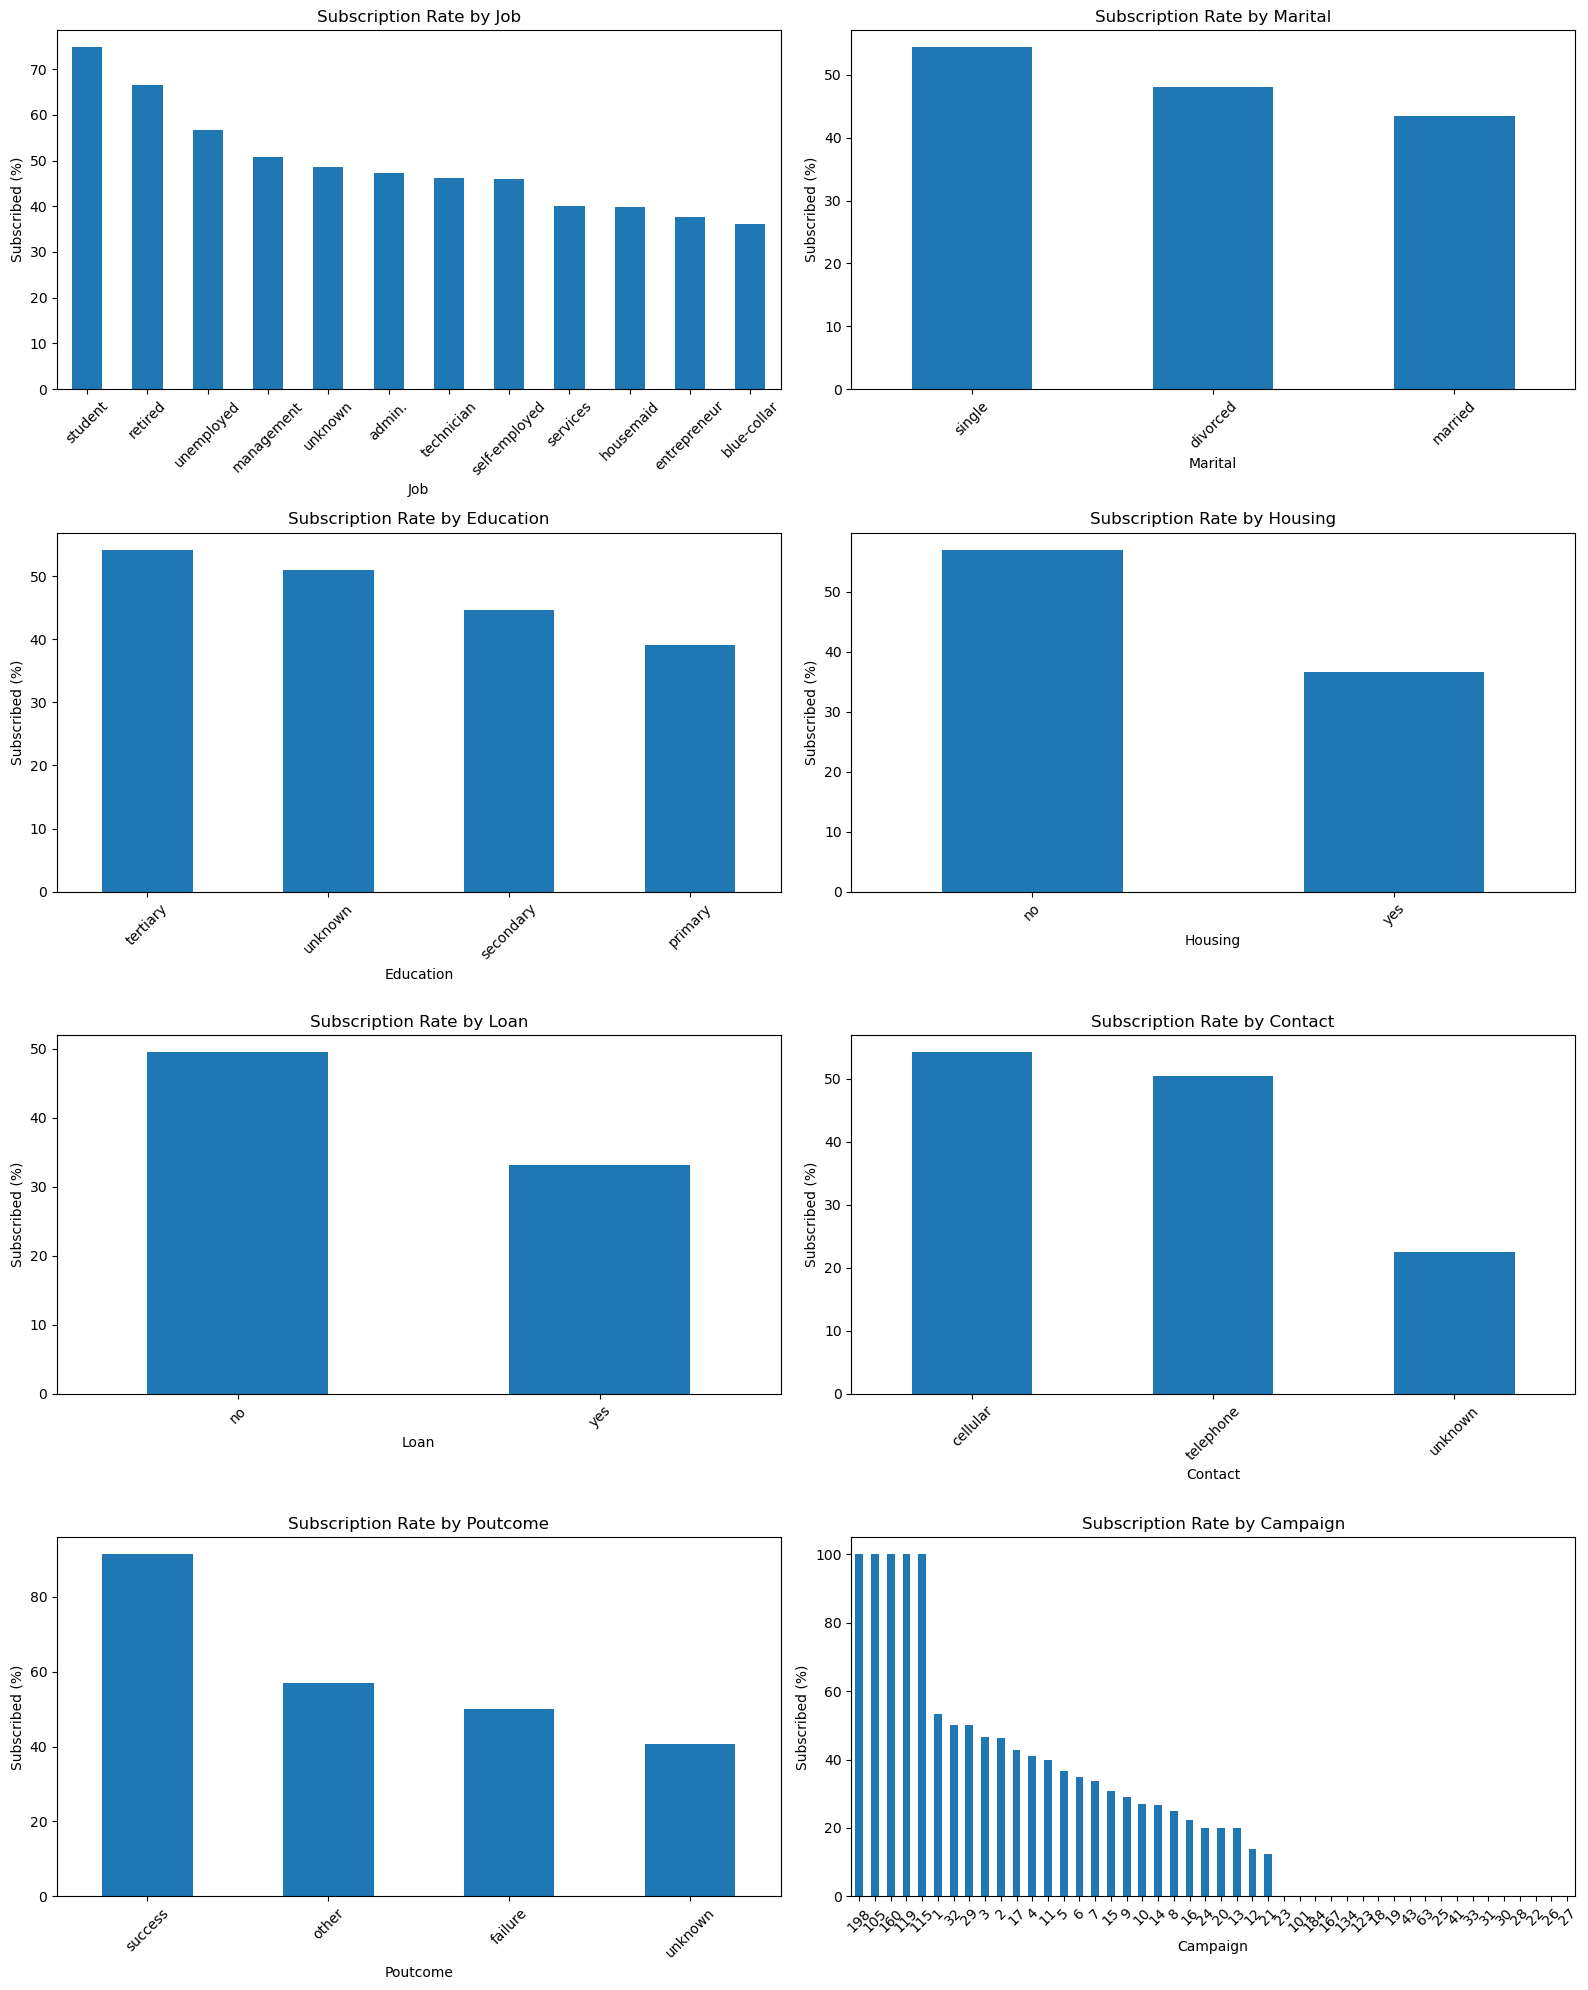

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# Factors we want to analyze
factors = [
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'poutcome',
    'campaign'
]

# Create one figure with multiple plots
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for ax, factor in zip(axes.flatten(), factors):

    # Calculate subscription percentage
    subscription_rate = pd.crosstab(
        df[factor],
        df['deposit'],
        normalize='index'
    ) * 100

    # Plot only subscribed percentage
    if 'yes' in subscription_rate.columns:
        subscription_rate['yes'].sort_values(ascending=False).plot(
            kind='bar',
            ax=ax
        )

    ax.set_title(f'Subscription Rate by {factor.capitalize()}')
    ax.set_xlabel(factor.capitalize())
    ax.set_ylabel('Subscribed (%)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [121]:
# Customers who subscribed
subscribed = df[df['deposit'] == 'yes']

print("Total subscribed customers:", len(subscribed))

# Job distribution among subscribed customers
print("\nJob distribution among subscribed customers:")
print(subscribed['job'].value_counts())

# Marital distribution among subscribed customers
print("\nMarital distribution among subscribed customers:")
print(subscribed['marital'].value_counts())

# Education distribution
print("\nEducation distribution:")
print(subscribed['education'].value_counts())

# Housing loan
print("\nHousing loan:")
print(subscribed['housing'].value_counts())

# Personal loan
print("\nPersonal loan:")
print(subscribed['loan'].value_counts())

# Contact method
print("\nContact method:")
print(subscribed['contact'].value_counts())

# Previous campaign outcome
print("\nPrevious campaign outcome:")
print(subscribed['poutcome'].value_counts())

Total subscribed customers: 5289

Job distribution among subscribed customers:
job
management       1290
technician        832
blue-collar       694
admin.            627
retired           512
services          367
student           266
unemployed        202
self-employed     184
entrepreneur      121
housemaid         109
unknown            34
Name: count, dtype: int64

Marital distribution among subscribed customers:
marital
married     2755
single      1912
divorced     622
Name: count, dtype: int64

Education distribution:
education
secondary    2428
tertiary     1979
primary       583
unknown       251
Name: count, dtype: int64

Housing loan:
housing
no     3354
yes    1935
Name: count, dtype: int64

Personal loan:
loan
no     4805
yes     484
Name: count, dtype: int64

Contact method:
contact
cellular     4324
unknown       525
telephone     388
Name: count, dtype: int64

Previous campaign outcome:
poutcome
unknown    3360
success     971
failure     605
other       302
Name: cou

In [122]:
marital_rate = pd.crosstab(
    df['marital'],
    df['deposit'],
    normalize='index'
) * 100

print(marital_rate)

deposit          no        yes
marital                       
divorced  51.894818  48.105182
married   56.621005  43.378995
single    45.650938  54.349062


In [123]:
job_rate = pd.crosstab(
    df['job'],
    df['deposit'],
    normalize='index'
) * 100

print(job_rate.sort_values('yes', ascending=False))

deposit               no        yes
job                                
student        25.280899  74.719101
retired        33.592737  66.407263
unemployed     43.417367  56.582633
management     49.292453  50.707547
unknown        51.428571  48.571429
admin.         52.714932  47.285068
technician     53.854687  46.145313
self-employed  54.114713  45.885287
services       59.978190  40.021810
housemaid      60.218978  39.781022
entrepreneur   62.422360  37.577640
blue-collar    63.872983  36.127017


In [124]:
mm_subscribed = df[
    (df['job'] == 'management') &
    (df['marital'] == 'married') &
    (df['deposit'] == 'yes')
]

print("Management + Married + Subscribed:", len(mm_subscribed))

print("\nEducation:")
print(mm_subscribed['education'].value_counts())

print("\nHousing:")
print(mm_subscribed['housing'].value_counts())

print("\nLoan:")
print(mm_subscribed['loan'].value_counts())

print("\nContact:")
print(mm_subscribed['contact'].value_counts())

print("\nPrevious campaign outcome:")
print(mm_subscribed['poutcome'].value_counts())

Management + Married + Subscribed: 675

Education:
education
tertiary     554
secondary     61
unknown       35
primary       21
Name: count, dtype: int64

Housing:
housing
no     459
yes    216
Name: count, dtype: int64

Loan:
loan
no     619
yes     56
Name: count, dtype: int64

Contact:
contact
cellular     587
telephone     42
unknown       39
Name: count, dtype: int64

Previous campaign outcome:
poutcome
unknown    391
success    142
failure     89
other       47
Name: count, dtype: int64


In [125]:
# 1. Job → Deposit

job_analysis = pd.crosstab(
    df['job'],
    df['deposit']
)

print(job_analysis)

job_rate = pd.crosstab(
    df['job'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(job_rate.round(2))

deposit          no   yes
job                      
admin.          699   627
blue-collar    1227   694
entrepreneur    201   121
housemaid       165   109
management     1254  1290
retired         259   512
self-employed   217   184
services        550   367
student          90   266
technician      971   832
unemployed      155   202
unknown          36    34

Subscription Rate:
deposit           no    yes
job                        
admin.         52.71  47.29
blue-collar    63.87  36.13
entrepreneur   62.42  37.58
housemaid      60.22  39.78
management     49.29  50.71
retired        33.59  66.41
self-employed  54.11  45.89
services       59.98  40.02
student        25.28  74.72
technician     53.85  46.15
unemployed     43.42  56.58
unknown        51.43  48.57


In [126]:
Which occupations have more subscribers, 
and which occupations have a higher subscription rate?

Insight

Number of management customers who subscribed
Number who didn't
Subscription rate for management
Compare it with other jobs

Recommendation

The bank can consider that occupational segment as a potentially responsive 
customer group and design targeted communication for similar customers.

SyntaxError: unterminated string literal (detected at line 7) (2949011441.py, line 7)

In [ ]:
# 2. Marital Status → Deposit

marital_analysis = pd.crosstab(
    df['marital'],
    df['deposit']
)

print(marital_analysis)

marital_rate = pd.crosstab(
    df['marital'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(marital_rate.round(2))

In [ ]:
# Among married, single and divorced customers, what percentage subscribed?

"Married customers represented a large share of subscribers, and their 
subscription rate can be compared with other marital groups."

In [ ]:
# 3. Education → Deposit

education_analysis = pd.crosstab(
    df['education'],
    df['deposit']
)

print(education_analysis)

education_rate = pd.crosstab(
    df['education'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(education_rate.round(2))

In [ ]:
# Does subscription behavior vary by education level?

In [ ]:
# 4. Housing → Deposit

housing_analysis = pd.crosstab(
    df['housing'],
    df['deposit']
)

print(housing_analysis)

housing_rate = pd.crosstab(
    df['housing'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(housing_rate.round(2))

In [ ]:
# Customers with housing loans vs customers without housing loans.

Customers without a housing loan could be investigated as a
potentially responsive segment.

In [ ]:
# 5. Personal Loan → Deposit

loan_analysis = pd.crosstab(
    df['loan'],
    df['deposit']
)

print(loan_analysis)

loan_rate = pd.crosstab(
    df['loan'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(loan_rate.round(2))

In [ ]:
# Do customers with personal loans and customers without personal loans respond
differently?

If customers without personal loans show a higher subscription rate,
this segment could be considered for targeted campaign testing.

In [ ]:
# 6. Contact Method → Deposit

contact_analysis = pd.crosstab(
    df['contact'],
    df['deposit']
)

print(contact_analysis)

contact_rate = pd.crosstab(
    df['contact'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(contact_rate.round(2))

In [ ]:
# Which contact method is associated with better campaign response?

The bank could test cellular-based communication for similar customers.

In [ ]:
# 7. Previous Campaign Outcome → Deposit

poutcome_analysis = pd.crosstab(
    df['poutcome'],
    df['deposit']
)

print(poutcome_analysis)

poutcome_rate = pd.crosstab(
    df['poutcome'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(poutcome_rate.round(2))

In [ ]:
# We are checking whether customers who previously:

succeeded
failed
had another outcome
had unknown history

respond differently in the current campaign.


Recommendation

Customers with a successful previous campaign interaction could be 
considered a high-priority segment for follow-up campaigns.

In [ ]:
# 8. Campaign → Deposit

campaign_analysis = pd.crosstab(
    df['campaign'],
    df['deposit']
)

print(campaign_analysis)

campaign_rate = pd.crosstab(
    df['campaign'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(campaign_rate.round(2))

In [ ]:
df['campaign_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 2, 3, 5, 10, float('inf')],
    labels=['1', '2', '3', '4-5', '6-10', '10+']
)

campaign_group_rate = pd.crosstab(
    df['campaign_group'],
    df['deposit'],
    normalize='index'
) * 100

print(campaign_group_rate.round(2))

In [ ]:
# Does repeated contact correspond to higher or lower subscription rates?

Recommendation

The bank could evaluate an appropriate follow-up frequency and 
avoid excessive repeated contacts when response remains low.

In [ ]:
# 9. Default → Deposit

default_analysis = pd.crosstab(
    df['default'],
    df['deposit']
)

print(default_analysis)

default_rate = pd.crosstab(
    df['default'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(default_rate.round(2))

In [127]:
# We are comparing customers:

with credit default history
without credit default history

This can help understand whether credit-default history is associated 
with campaign response.

SyntaxError: invalid syntax (3209726449.py, line 3)

In [128]:
# 10. Month → Deposit

month_analysis = pd.crosstab(
    df['month'],
    df['deposit']
)

print(month_analysis)

month_rate = pd.crosstab(
    df['month'],
    df['deposit'],
    normalize='index'
) * 100

print("\nSubscription Rate:")
print(month_rate.round(2))

deposit    no  yes
month             
apr       346  577
aug       831  688
dec        10  100
feb       335  441
jan       202  142
jul       887  627
jun       676  546
mar        28  248
may      1899  925
nov       540  403
oct        69  323
sep        50  269

Subscription Rate:
deposit     no    yes
month                
apr      37.49  62.51
aug      54.71  45.29
dec       9.09  90.91
feb      43.17  56.83
jan      58.72  41.28
jul      58.59  41.41
jun      55.32  44.68
mar      10.14  89.86
may      67.25  32.75
nov      57.26  42.74
oct      17.60  82.40
sep      15.67  84.33


In [129]:
# During which months was the campaign associated with higher subscription rates?

# Recommendation

If certain months consistently show higher response:

The bank could consider testing increased campaign activity during those periods.

SyntaxError: invalid syntax (3667485228.py, line 5)

In [144]:
# 11. Balance → Deposit

df.groupby('deposit'
          )['balance'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
deposit,,,,,
no,5792,1236.397963,414.5,-250000.0,350000.0
yes,5245,2197.219066,733.0,-150000.0,500000.0


In [ ]:
# How does the financial balance distribution differ between subscribers and non-subscribers?

If subscribers have a different balance profile:

Balance can be considered as one segmentation variable when identifying 
customers for future  campaign analysis.

In [130]:
# 12. Age → Deposit

df.groupby('deposit')['age'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
deposit,,,,,
no,5873,40.783416,39.0,18.0,89.0
yes,5289,41.633957,38.0,18.0,95.0


In [131]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

age_rate = pd.crosstab(
    df['age_group'],
    df['deposit'],
    normalize='index'
) * 100

print(age_rate.round(2))

deposit       no    yes
age_group              
18-25      29.21  70.79
26-35      52.39  47.61
36-45      58.50  41.50
46-55      58.40  41.60
56-65      45.83  54.17
66+        19.64  80.36


In [ ]:
# Which age groups show relatively higher subscription rates?

Recommendation

The bank could test different campaign messaging across age segments
rather than using exactly  the same communication for everyone.

In [132]:
# COMBINATIONS

pd.crosstab(
    [df['job'], df['marital']],
    df['deposit'],
    normalize='index'
) * 100

deposit                        no        yes
job           marital                       
admin.        divorced  50.000000  50.000000
              married   54.881657  45.118343
              single    50.638298  49.361702
blue-collar   divorced  61.073826  38.926174
              married   67.501898  32.498102
              single    54.285714  45.714286
entrepreneur  divorced  65.853659  34.146341
              married   65.065502  34.934498
              single    48.076923  51.923077
housemaid     divorced  60.869565  39.130435
              married   64.736842  35.263158
              single    36.842105  63.157895
management    divorced  50.871080  49.128920
              married   52.296820  47.703180
              single    43.705463  56.294537
retired       divorced  28.994083  71.005917
              married   34.201389  65.798611
              single    50.000000  50.000000
self-employed divorced  45.945946  54.054054
              married   64.545455  35.454545
              single    40.277778  59.722222
services      divorced  58.677686  41.322314
              married   64.729459  35.270541
              single    52.525253  47.474747
student       divorced  50.000000  50.000000
              married   33.333333  66.666667
              single    24.778761  75.221239
technician    divorced  62.561576  37.438424
              married   55.168662  44.831338
              single    49.486050  50.513950
unemployed    divorced  42.553191  57.446809
              married   47.849462  52.150538
              single    37.096774  62.903226
unknown       divorced  50.000000  50.000000
              married   57.142857  42.857143
              single    36.842105  63.157895

In [ ]:
# We are looking for segments with relatively high subscription rates

In [133]:
# Job + Education
pd.crosstab(
    [df['job'], df['education']],
    df['deposit'],
    normalize='index'
) * 100

deposit                         no        yes
job           education                      
admin.        primary    71.428571  28.571429
              secondary  53.701968  46.298032
              tertiary   41.317365  58.682635
              unknown    56.410256  43.589744
blue-collar   primary    68.722467  31.277533
              secondary  61.630037  38.369963
              tertiary   47.826087  52.173913
              unknown    61.904762  38.095238
entrepreneur  primary    70.000000  30.000000
              secondary  63.503650  36.496350
              tertiary   61.240310  38.759690
              unknown    50.000000  50.000000
housemaid     primary    65.972222  34.027778
              secondary  56.410256  43.589744
              tertiary   48.837209  51.162791
              unknown    55.555556  44.444444
management    primary    66.666667  33.333333
              secondary  58.723404  41.276596
              tertiary   47.913737  52.086263
              unknown    43.373494  56.626506
retired       primary    35.687732  64.312268
              secondary  34.201954  65.798046
              tertiary   27.857143  72.142857
              unknown    36.956522  63.043478
self-employed primary    82.142857  17.857143
              secondary  68.656716  31.343284
              tertiary   41.592920  58.407080
              unknown    54.545455  45.454545
services      primary    65.853659  34.146341
              secondary  59.972863  40.027137
              tertiary   53.846154  46.153846
              unknown    53.658537  46.341463
student       primary    23.809524  76.190476
              secondary  20.765027  79.234973
              tertiary   28.750000  71.250000
              unknown    33.846154  66.153846
technician    primary    68.292683  31.707317
              secondary  57.118787  42.881213
              tertiary   44.793713  55.206287
              unknown    54.901961  45.098039
unemployed    primary    39.285714  60.714286
              secondary  48.792271  51.207729
              tertiary   33.333333  66.666667
              unknown    42.857143  57.142857
unknown       primary    57.142857  42.857143
              secondary  40.000000  60.000000
              tertiary   55.555556  44.444444
              unknown    53.846154  46.153846

In [149]:
# Job + Housing
pd.crosstab(
    [df['job'], df['housing']],
    df['deposit'],
    normalize='index'
) * 100

deposit                       no        yes
job           housing                      
admin.        no       42.229730  57.770270
              yes      61.171662  38.828338
blue-collar   no       56.585366  43.414634
              yes      67.304747  32.695253
entrepreneur  no       56.962025  43.037975
              yes      67.682927  32.317073
housemaid     no       57.070707  42.929293
              yes      68.421053  31.578947
management    no       41.863606  58.136394
              yes      59.642521  40.357479
retired       no       29.012346  70.987654
              yes      57.723577  42.276423
self-employed no       48.471616  51.528384
              yes      61.627907  38.372093
services      no       48.587571  51.412429
              yes      67.140320  32.859680
student       no       19.934641  80.065359
              yes      58.000000  42.000000
technician    no       46.908316  53.091684
              yes      61.387283  38.612717
unemployed    no       33.877551  66.122449
              yes      64.285714  35.714286
unknown       no       52.238806  47.761194
              yes      33.333333  66.666667

In [134]:
# Marital + Housing
pd.crosstab(
    [df['marital'], df['housing']],
    df['deposit'],
    normalize='index'
) * 100

deposit                  no        yes
marital  housing                      
divorced no       44.161677  55.838323
         yes      60.160000  39.840000
married  no       46.210721  53.789279
         yes      67.504026  32.495974
single   no       37.214032  62.785968
         yes      56.350741  43.649259

In [135]:
job_marital_rate = pd.crosstab(
    [df['job'], df['marital']],
    df['deposit'],
    normalize='index'
) * 100

print(job_marital_rate.round(2))

deposit                    no    yes
job           marital               
admin.        divorced  50.00  50.00
              married   54.88  45.12
              single    50.64  49.36
blue-collar   divorced  61.07  38.93
              married   67.50  32.50
              single    54.29  45.71
entrepreneur  divorced  65.85  34.15
              married   65.07  34.93
              single    48.08  51.92
housemaid     divorced  60.87  39.13
              married   64.74  35.26
              single    36.84  63.16
management    divorced  50.87  49.13
              married   52.30  47.70
              single    43.71  56.29
retired       divorced  28.99  71.01
              married   34.20  65.80
              single    50.00  50.00
self-employed divorced  45.95  54.05
              married   64.55  35.45
              single    40.28  59.72
services      divorced  58.68  41.32
              married   64.73  35.27
              single    52.53  47.47
student       divorced  50.00  50.00
 

In [ ]:
# 2. Interesting high-subscription segments

From your output:

Job + Marital	Subscribed
Student + Single	75.22%
Retired + Divorced	71.01%
Student + Married	66.67%
Retired + Married	65.80%
Housemaid + Single	63.16%
Unemployed + Single	62.90%
Self-employed + Single	59.72%
Unemployed + Divorced	57.45%
Management + Single	56.29%

These are subscription rates, not simply the number of subscribers.

In [ ]:
# Being married by itself is not enough to explain subscription.

The subscription rate varies substantially depending on the job
+ marital combination.

In [136]:
#  Find the actual number of customers

job_marital_counts = pd.crosstab(
    [df['job'], df['marital']],
    df['deposit']
)


print(job_marital_counts)

deposit                  no  yes
job           marital           
admin.        divorced   90   90
              married   371  305
              single    238  232
blue-collar   divorced   91   58
              married   889  428
              single    247  208
entrepreneur  divorced   27   14
              married   149   80
              single     25   27
housemaid     divorced   28   18
              married   123   67
              single     14   24
management    divorced  146  141
              married   740  675
              single    368  474
retired       divorced   49  120
              married   197  379
              single     13   13
self-employed divorced   17   20
              married   142   78
              single     58   86
services      divorced   71   50
              married   323  176
              single    156  141
student       divorced    1    1
              married     5   10
              single     84  255
technician    divorced  127   76
          

In [153]:
job_marital_counts = pd.crosstab(
    [df['job'], df['marital']],
    df['deposit']
)

print(job_marital_counts)

deposit                  no  yes
job           marital           
admin.        divorced   90   90
              married   371  305
              single    238  232
blue-collar   divorced   91   58
              married   889  428
              single    247  208
entrepreneur  divorced   27   14
              married   149   80
              single     25   27
housemaid     divorced   28   18
              married   123   67
              single     14   24
management    divorced  146  141
              married   740  675
              single    368  474
retired       divorced   49  120
              married   197  379
              single     13   13
self-employed divorced   17   20
              married   142   78
              single     58   86
services      divorced   71   50
              married   323  176
              single    156  141
student       divorced    1    1
              married     5   10
              single     84  255
technician    divorced  127   76
          

In [ ]:
# Your strongest segments include:
Job + Marital	Total	Subscribed	Not subscribed	Subscription rate
Student + Single	339	255	84	75.22%
Retired + Divorced	169	120	49	71.01%
Retired + Married	576	379	197	65.80%
Student + Married	15	10	5	66.67%
Housemaid + Single	38	24	14	63.16%
Unemployed + Single	124	78	46	62.90%
Self-employed + Single	144	86	58	59.72%
Management + Single	842	474	368  56.29%

In [ ]:
# Insight

Management + married has the largest number of customers,
but management + single has the higher subscription rate.


In [137]:
# Student + Single
student_single = df[
    (df['job'] == 'student') &
    (df['marital'] == 'single')
]

print("Student + Single")
print(student_single.groupby('deposit')[[
    'age', 'balance', 'campaign', 'previous'
]].agg(['count', 'mean', 'median']))

Student + Single
          age                   balance                     campaign  \
        count       mean median   count         mean median    count   
deposit                                                                
no         84  26.702381   26.0      83  1559.951807  493.0       84   
yes       255  25.674510   25.0     251  1534.868526  538.0      255   

                         previous                   
             mean median    count      mean median  
deposit                                             
no       2.619048    2.0       84  1.178571    0.0  
yes      1.972549    1.0      255  1.352941    0.0  


In [138]:
# Retired + Married
retired_married = df[
    (df['job'] == 'retired') &
    (df['marital'] == 'married')
]

print("Retired + Married")
print(retired_married.groupby('deposit')[[
    'age', 'balance', 'campaign', 'previous'
]].agg(['count', 'mean', 'median']))

Retired + Married
          age                   balance                      campaign  \
        count       mean median   count         mean  median    count   
deposit                                                                 
no        197  60.817259   59.0     196  1939.265306   611.5      197   
yes       379  66.949868   67.0     376  4624.590426  1600.0      379   

                         previous                   
             mean median    count      mean median  
deposit                                             
no       2.654822    2.0      197  0.568528    0.0  
yes      1.802111    1.0      379  1.408971    0.0  


In [139]:
# Management + Married
management_married = df[
    (df['job'] == 'management') &
    (df['marital'] == 'married')
]

print("Management + Married")
print(management_married.groupby('deposit')[[
    'age', 'balance', 'campaign', 'previous'
]].agg(['count', 'mean', 'median']))

Management + Married
          age                   balance                     campaign  \
        count       mean median   count         mean median    count   
deposit                                                                
no        740  42.377027   41.0     732  1911.565574  397.0      740   
yes       675  43.699259   42.0     664  1817.213855  994.0      675   

                         previous                   
             mean median    count      mean median  
deposit                                             
no       3.370270    2.0      740  0.481081    0.0  
yes      2.275556    2.0      675  1.383704    0.0  


In [140]:
student_single = df[
    (df['job'] == 'student') &
    (df['marital'] == 'single')
]

for col in ['education', 'housing', 'loan', 'contact', 'poutcome']:

    print("\n==============================")
    print(col.upper())
    print("==============================")

    result = pd.crosstab(
        student_single[col],
        student_single['deposit'],
        normalize='index'
    ) * 100

    print(result.round(2))


EDUCATION
deposit       no    yes
education              
primary    21.05  78.95
secondary  20.45  79.55
tertiary   27.03  72.97
unknown    34.92  65.08

HOUSING
deposit     no    yes
housing              
no       19.32  80.68
yes      61.36  38.64

LOAN
deposit      no    yes
loan                  
no        24.56  75.44
yes      100.00   0.00

CONTACT
deposit       no    yes
contact                
cellular   20.27  79.73
telephone  35.71  64.29
unknown    76.47  23.53

POUTCOME
deposit      no    yes
poutcome              
failure   21.62  78.38
other     25.81  74.19
success    7.81  92.19
unknown   30.39  69.61


In [141]:
# Detailed EDA

In [142]:
# 1. Univariate Analysis — One variable

Deposit Distribution — understand target variable
Job Distribution — understand customer occupation
Age Distribution — understand customer age pattern

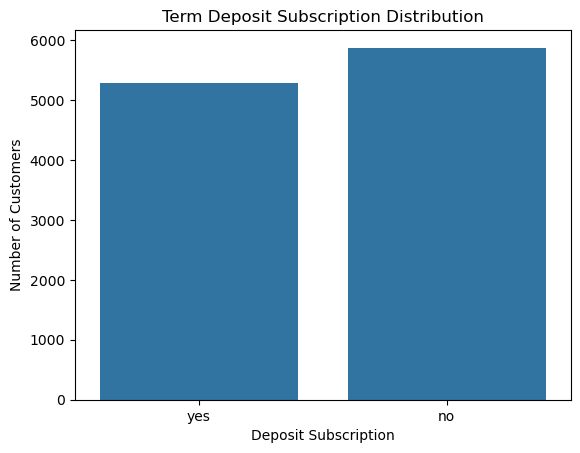

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='deposit')

plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Deposit Subscription')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# The target variable is relatively balanced, with 47.38% of customers 
subscribing to the term deposit and 52.62% not subscribing. 
Therefore, there is no severe class imbalance in the dataset.

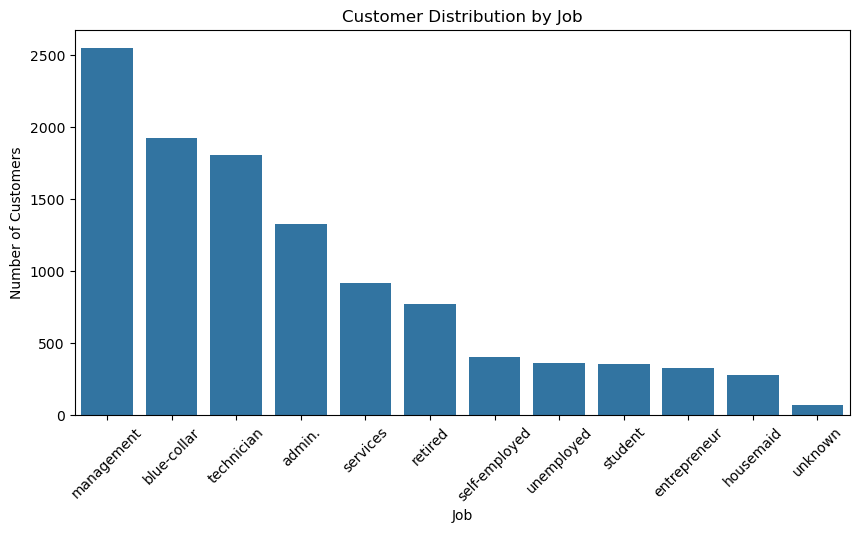

In [144]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='job',
    order=df['job'].value_counts().index
)

plt.title('Customer Distribution by Job')
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

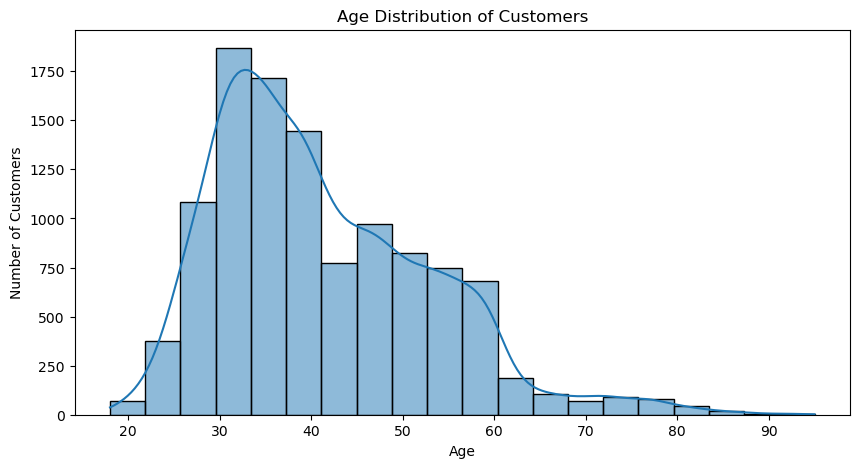

In [145]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True
)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# Which age range contains most customers?
Is the distribution concentrated or spread out?
Are there unusually high/low age values?

After our cleaning, the valid age range is 18–95.

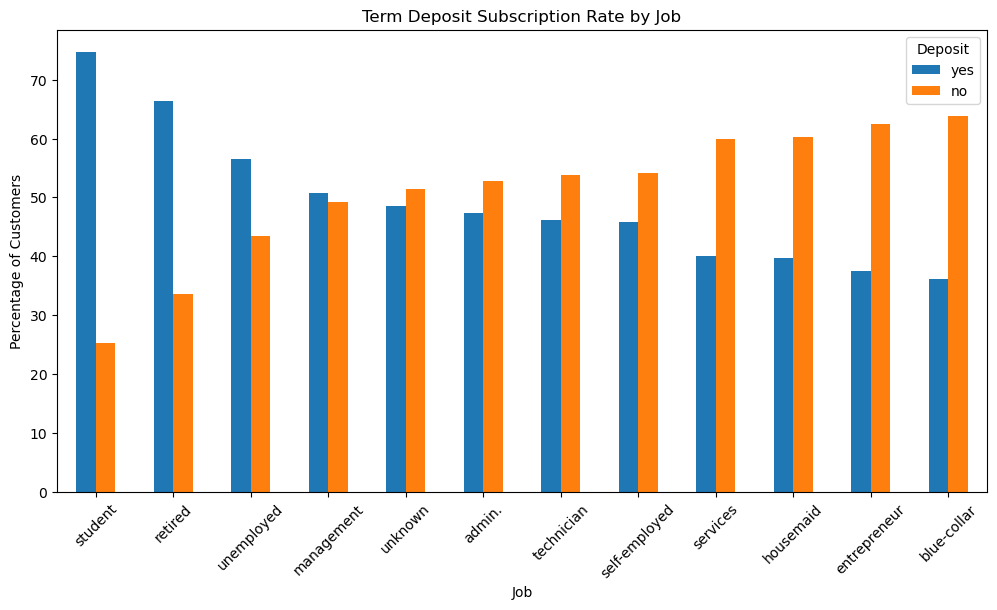

In [146]:
job_deposit_rate = (
    pd.crosstab(df['job'], df['deposit'], normalize='index') * 100
)

job_deposit_rate = job_deposit_rate.sort_values('yes', ascending=False)

job_deposit_rate[['yes', 'no']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Term Deposit Subscription Rate by Job')
plt.xlabel('Job')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45)
plt.legend(title='Deposit')
plt.show()

In [147]:
# Bivariate Analysis

# Education vs Deposit

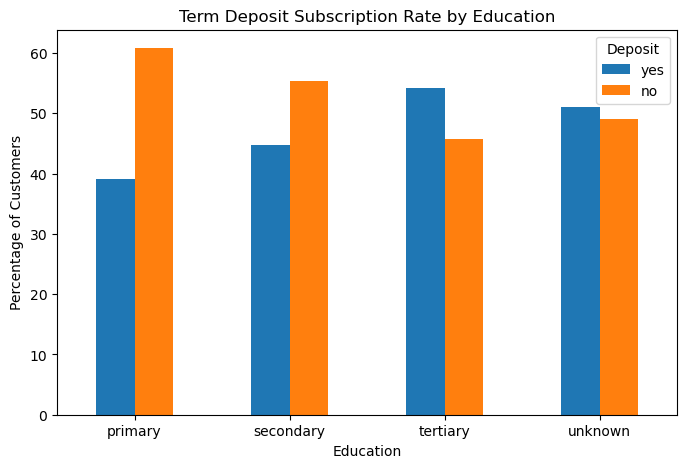

In [148]:
education_deposit = (
    pd.crosstab(
        df['education'],
        df['deposit'],
        normalize='index'
    ) * 100
)

education_deposit[['yes', 'no']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Term Deposit Subscription Rate by Education')
plt.xlabel('Education')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Deposit')
plt.show()

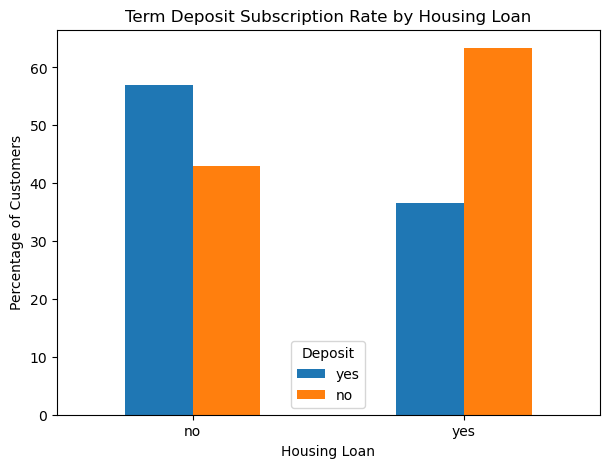

In [149]:
housing_deposit = (
    pd.crosstab(
        df['housing'],
        df['deposit'],
        normalize='index'
    ) * 100
)

housing_deposit[['yes', 'no']].plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Term Deposit Subscription Rate by Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Deposit')
plt.show()

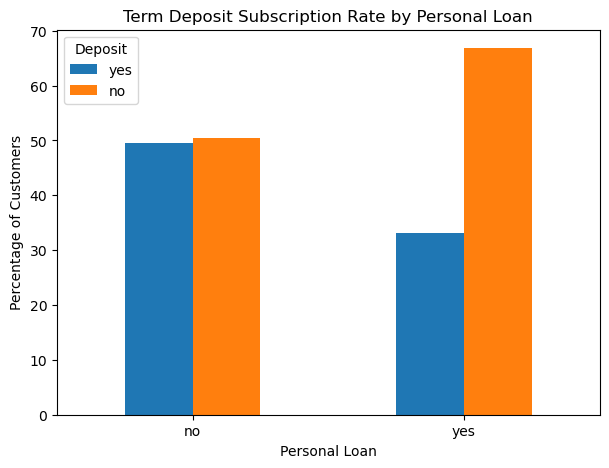

In [150]:
loan_deposit = (
    pd.crosstab(
        df['loan'],
        df['deposit'],
        normalize='index'
    ) * 100
)

loan_deposit[['yes', 'no']].plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Term Deposit Subscription Rate by Personal Loan')
plt.xlabel('Personal Loan')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Deposit')
plt.show()

In [152]:
# Important Multivariate Graphs

# Job + Marital + Deposit

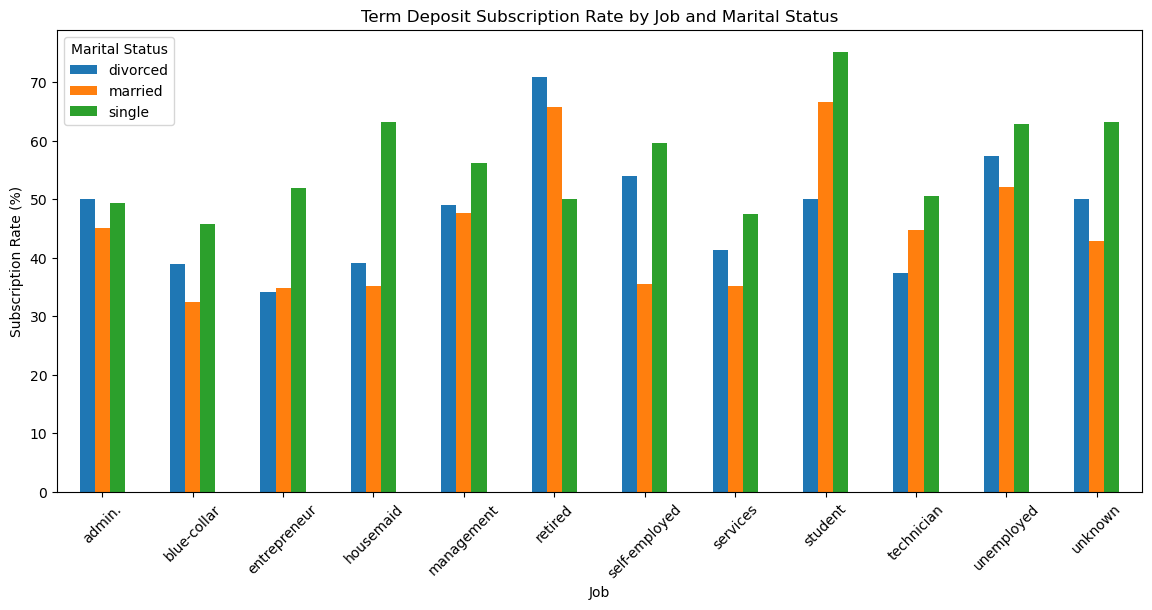

In [153]:
job_marital_deposit = (
    pd.crosstab(
        [df['job'], df['marital']],
        df['deposit'],
        normalize='index'
    ) * 100
)

job_marital_deposit['yes'].unstack().plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Term Deposit Subscription Rate by Job and Marital Status')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Marital Status')
plt.show()

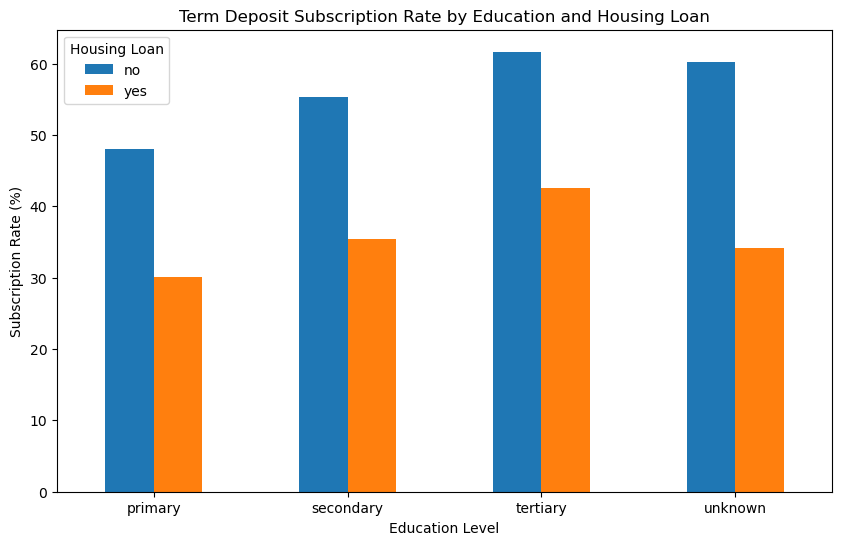

In [154]:
education_housing = (
    pd.crosstab(
        [df['education'], df['housing']],
        df['deposit'],
        normalize='index'
    ) * 100
)

education_housing['yes'].unstack().plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Term Deposit Subscription Rate by Education and Housing Loan')
plt.xlabel('Education Level')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Housing Loan')
plt.show()

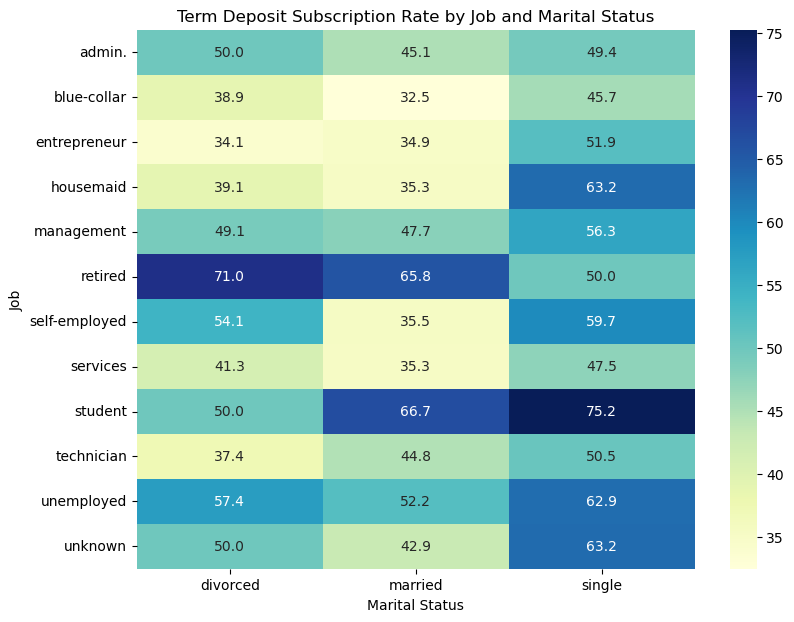

In [155]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate subscription rate
heatmap_data = (
    df.assign(
        subscribed=(df['deposit'] == 'yes').astype(int)
    )
    .pivot_table(
        index='job',
        columns='marital',
        values='subscribed',
        aggfunc='mean'
    ) * 100
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Term Deposit Subscription Rate by Job and Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Job')
plt.show()

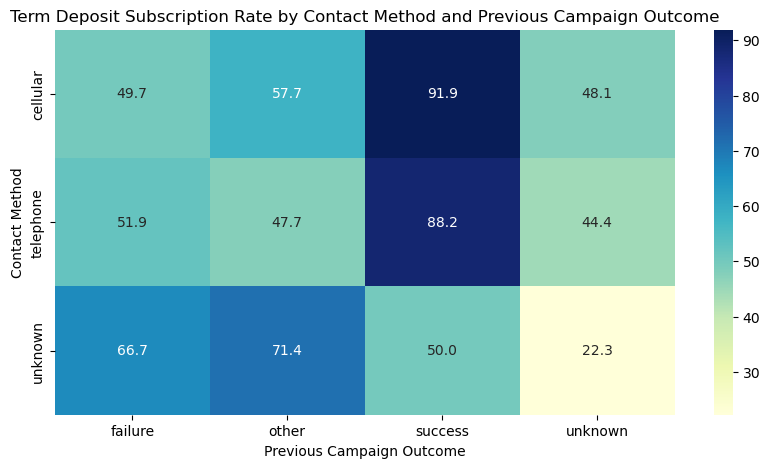

In [156]:
contact_poutcome = (
    df.assign(
        subscribed=(df['deposit'] == 'yes').astype(int)
    )
    .pivot_table(
        index='contact',
        columns='poutcome',
        values='subscribed',
        aggfunc='mean'
    ) * 100
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    contact_poutcome,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Term Deposit Subscription Rate by Contact Method and Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Contact Method')
plt.show()

In [ ]:
# Statistical Analysis


In [ ]:
# For our Bank Marketing project, the most important tests are:

# Chi-Square Test → categorical variables vs deposit
# T-Test → numerical variable vs deposit
# P-value interpretation → decide statistical significance
# Correlation analysis → relationship between numerical variables

In [157]:
from scipy.stats import chi2_contingency

In [158]:
table = pd.crosstab(df['housing'], df['deposit'])

print(table)

deposit    no   yes
housing            
no       2527  3354
yes      3346  1935


In [159]:
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)

Chi-Square Statistic: 463.1892407533161
P-value: 9.724394114495535e-103


In [161]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
    print("There is a statistically significant association.")
else:
    print("Fail to reject the null hypothesis")
    print("There is no statistically significant association.")

Reject the null hypothesis
There is a statistically significant association.


In [162]:
categorical_test_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

for col in categorical_test_cols:
    
    table = pd.crosstab(df[col], df['deposit'])
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    print(f"{col}: p-value = {p_value:.6f}")

job: p-value = 0.000000
marital: p-value = 0.000000
education: p-value = 0.000000
default: p-value = 0.000024
housing: p-value = 0.000000
loan: p-value = 0.000000
contact: p-value = 0.000000
month: p-value = 0.000000
poutcome: p-value = 0.000000


In [164]:
for col in categorical_test_cols:
    
    table = pd.crosstab(df[col], df['deposit'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    print(f"{col}: {p_value:.12f}")

for col in categorical_test_cols:
    
    table = pd.crosstab(df[col], df['deposit'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    print(f"{col}: {p_value:.12f}")

job: 0.000000000000
marital: 0.000000000000
education: 0.000000000000
default: 0.000024428002
housing: 0.000000000000
loan: 0.000000000000
contact: 0.000000000000
month: 0.000000000000
poutcome: 0.000000000000
job: 0.000000000000
marital: 0.000000000000
education: 0.000000000000
default: 0.000024428002
housing: 0.000000000000
loan: 0.000000000000
contact: 0.000000000000
month: 0.000000000000
poutcome: 0.000000000000


In [165]:
# T-Test — Numerical Variables 📊

In [166]:
from scipy.stats import ttest_ind

yes_group = df[df['deposit'] == 'yes']
no_group = df[df['deposit'] == 'no']

In [167]:
numeric_test_cols = [
    'age',
    'balance',
    'duration',
    'campaign',
    'previous'
]


In [168]:
for col in numeric_test_cols:
    
    t_stat, p_value = ttest_ind(
        yes_group[col],
        no_group[col],
        equal_var=False,
        nan_policy='omit'
    )
    
    print(f"{col}:")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value = {p_value:.6f}")
    print()

age:
t-statistic = 3.7438
p-value = 0.000182

balance:
t-statistic = 4.4983
p-value = 0.000007

duration:
t-statistic = 27.7844
p-value = 0.000000

campaign:
t-statistic = -7.2332
p-value = 0.000000

previous:
t-statistic = 14.7291
p-value = 0.000000



In [169]:
# P-value Interpretation + Effect Size

In [170]:
for col in numeric_test_cols:
    print(f"\n{col}")
    print("Subscribed mean:", yes_group[col].mean())
    print("Not subscribed mean:", no_group[col].mean())


age
Subscribed mean: 41.63395726980526
Not subscribed mean: 40.78341563085306

balance
Subscribed mean: 2197.2190657769306
Not subscribed mean: 1236.3979627071824

duration
Subscribed mean: 550.6824608330149
Not subscribed mean: 240.83115093039282

campaign
Subscribed mean: 2.2709396861410474
Not subscribed mean: 2.9570917759237187

previous
Subscribed mean: 1.1703535640007563
Not subscribed mean: 0.5283500766218288


In [171]:
#  Feature Engineering 📊

In [172]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '66+'
    ]
)

In [173]:
df['age_group'].value_counts().sort_index()

age_group
18-25     445
26-35    3873
36-45    3265
46-55    2120
56-65    1067
66+       392
Name: count, dtype: int64

In [174]:
df['campaign_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 2, 3, 5, 10, float('inf')],
    labels=['1', '2', '3', '4-5', '6-10', '10+']
)

In [175]:
df['campaign_group'].value_counts().sort_index()

campaign_group
1       4794
2       3027
3       1318
4-5     1149
6-10     654
10+      220
Name: count, dtype: int64

In [176]:
df['previous_group'] = pd.cut(
    df['previous'],
    bins=[-1, 0, 1, 3, float('inf')],
    labels=[
        'No Previous Contact',
        '1 Previous Contact',
        '2-3 Previous Contacts',
        '4+ Previous Contacts'
    ]
)

In [177]:
df['previous_group'].value_counts().sort_index()

previous_group
No Previous Contact      8324
1 Previous Contact        887
2-3 Previous Contacts    1128
4+ Previous Contacts      823
Name: count, dtype: int64

In [178]:
engineered_cols = [
    'age_group',
    'campaign_group',
    'previous_group'
]

for col in engineered_cols:
    
    print("\n==============================")
    print(col.upper())
    print("==============================")
    
    result = pd.crosstab(
        df[col],
        df['deposit'],
        normalize='index'
    ) * 100
    
    print(result.round(2))


AGE_GROUP
deposit       no    yes
age_group              
18-25      29.21  70.79
26-35      52.39  47.61
36-45      58.50  41.50
46-55      58.40  41.60
56-65      45.83  54.17
66+        19.64  80.36

CAMPAIGN_GROUP
deposit            no    yes
campaign_group              
1               46.62  53.38
2               53.75  46.25
3               53.26  46.74
4-5             60.31  39.69
6-10            68.50  31.50
10+             76.36  23.64

PREVIOUS_GROUP
deposit                   no    yes
previous_group                     
No Previous Contact    59.35  40.65
1 Previous Contact     34.27  65.73
2-3 Previous Contacts  33.51  66.49
4+ Previous Contacts   30.50  69.50


In [179]:
for col in engineered_cols:
    print("\n==============================")
    print(col.upper())
    print("==============================")
    
    print(
        pd.crosstab(
            df[col],
            df['deposit']
        )
    )


AGE_GROUP
deposit      no   yes
age_group            
18-25       130   315
26-35      2029  1844
36-45      1910  1355
46-55      1238   882
56-65       489   578
66+          77   315

CAMPAIGN_GROUP
deposit           no   yes
campaign_group            
1               2235  2559
2               1627  1400
3                702   616
4-5              693   456
6-10             448   206
10+              168    52

PREVIOUS_GROUP
deposit                  no   yes
previous_group                   
No Previous Contact    4940  3384
1 Previous Contact      304   583
2-3 Previous Contacts   378   750
4+ Previous Contacts    251   572


In [180]:
# Final Business Insights